# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [ ]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras
from src.config import clean_data_file, reports_folder
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31772 entries, 4 to 35309
Data columns (total 78 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   CashAndCashEquivalents                  31772 non-null  float64       
 1   CurrentDebt                             31772 non-null  float64       
 2   LongTermDebt                            31772 non-null  float64       
 3   TotalDebt                               31772 non-null  float64       
 4   StockholdersEquity                      31772 non-null  float64       
 5   TotalAssets                             31772 non-null  float64       
 6   CurrentAssets                           31772 non-null  float64       
 7   CurrentLiabilities                      31772 non-null  float64       
 8   TotalNoncurrentLiabilities              31772 non-null  float64       
 9   TotalLiabilities                        31772 non-null 

## Feature Engineering

In [ ]:
# Sección reservada para crear variables en la fase de modelado. 

## Modelo de ensamblado de árboles RandomForest

In [ ]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Label
    'MonthlyExcessReturn_Quantile',
    # Variables de volumen y precios crudos: 
    # No tiene sentido utilizarlas habiendo multiples tickers
    'Open',
    'Close',    
    'AverageDailyVolume_Lag1',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource'
    ]

# Se define la variable objetivo (categórica) y las variables predictoras
label = 'MonthlyExcessReturn_Quantile'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

# Reemplazo de RandomForestRegressor por RandomForestClassifier
pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo clasificador con datos completos...")
pipe.fit(X, y)
accuracy_completa = pipe.score(X, y)
print(f"Entrenamiento finalizado. Accuracy en datos completos: {accuracy_completa:.4f}")

Entrenando el modelo clasificador con datos completos...
Entrenamiento finalizado. Accuracy en datos completos: 0.5588


In [7]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='accuracy',
    n_jobs=-1        
)

print(f"Accuracy promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

Accuracy promedio Time Series CV: 0.2383 ± 0.0104


In [8]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
40,num__ShortTermBeta_Yeo,0.050297
31,num__MonthlyReturn_Lag1_Yeo,0.041317
43,num__ProfitMargins_Yeo,0.038914
36,num__AverageDailyVolume_Lag1_QoQ_Yeo,0.038323
44,num__ReturnOnAssets_Yeo,0.036338
27,num__AverageDailyVolume_Lag1_Acceleration,0.034562
30,num__MarketCap_Log1p,0.034020
48,cat__Industry,0.033878
19,num__AssetToMarket,0.033721
18,num__RevenueYield,0.031636


In [ ]:
# Visualizar distribución de features
X.describe().T

## Aplicación del modelo

In [9]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train, X_test, y_train, y_test = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Predicciones de la clase (Quintil 1 al 5)
y_pred_class = pipe.predict(X_test)

# Predicciones de probabilidad para desempatar y rankear
y_pred_proba = pipe.predict_proba(X_test)

# Extraer el modelo final del pipeline para conocer el orden de las clases
rf_model = pipe.named_steps['model']

# Identificar el índice de la columna que contiene la probabilidad del Quintil 5
idx_q5 = list(rf_model.classes_).index(5)
proba_q5 = y_pred_proba[:, idx_q5]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Construir el DataFrame de resultados directamente (reemplaza 'procesar_resultados_prediccion')
resultados_agrupados = pd.DataFrame({
    'Ticker': tickers_test.values,
    'Observed_Quantile': y_test.values,
    'Predicted_Quantile': y_pred_class,
    'Probability_Q5': proba_q5
})

# Generar una señal (Cluster) de recomendación basada en la predicción del modelo
resultados_agrupados['Signal'] = np.where(
    resultados_agrupados['Predicted_Quantile'] == 5, 'Top_Quintile (Buy)', 
    np.where(resultados_agrupados['Predicted_Quantile'] == 1, 'Bottom_Quintile (Sell)', 'Neutral')
)

In [10]:
# Ordenar resultados por la probabilidad de pertenecer al Quintil 5 (de mayor a menor confianza)
resultados_agrupados = resultados_agrupados.sort_values(by='Probability_Q5', ascending=False)

# Mostrar el Top 10 de oportunidades según el modelo
print(resultados_agrupados.head(10).to_string(index=False))

Ticker  Observed_Quantile  Predicted_Quantile  Probability_Q5             Signal
   WDC                  1                   5        0.436323 Top_Quintile (Buy)
   AMN                  5                   5        0.430156 Top_Quintile (Buy)
    MU                  1                   5        0.403040 Top_Quintile (Buy)
  CNDT                  5                   5        0.372412 Top_Quintile (Buy)
   AMD                  1                   5        0.369530 Top_Quintile (Buy)
    GO                  5                   5        0.363912 Top_Quintile (Buy)
   RIG                  5                   5        0.354392 Top_Quintile (Buy)
  MRNA                  5                   5        0.348403 Top_Quintile (Buy)
   HUM                  3                   5        0.346055 Top_Quintile (Buy)
   TER                  1                   5        0.344631 Top_Quintile (Buy)


In [11]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

# Crear carpeta si no existe y nombrar el archivo con la fecha
reports_folder.mkdir(parents=True, exist_ok=True)
nombre_archivo = f"{year}_{mes}_{dia}.csv"
ruta_completa = reports_folder / nombre_archivo

df_reporte.to_csv(ruta_completa, index=False)
print(f'Reporte exportado en la carpeta de datos.')
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Observed_Quantile,Predicted_Quantile,Probability_Q5,Signal,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,CurrentAssets,CurrentLiabilities,TotalNoncurrentLiabilities,TotalLiabilities,OperatingCashFlow_TTM,InvestingCashFlow_TTM,FinancingCashFlow_TTM,FreeCashFlow_TTM,CapitalExpenditure_TTM,DepreciationAndAmortization_TTM,TotalRevenue_TTM,GrossProfit_TTM,OperatingIncome_TTM,NetIncome_TTM,EBITDA_TTM,BasicAverageShares_TTM,TotalRevenue_TTM_QoQ_IsMissing,EBITDA_TTM_QoQ_IsMissing,FreeCashFlow_TTM_QoQ_IsMissing,CapitalExpenditure_TTM_QoQ_IsMissing,AverageDailyVolume_Lag1_QoQ_IsMissing,TotalRevenue_TTM_YoY_IsMissing,EBITDA_TTM_YoY_IsMissing,FreeCashFlow_TTM_YoY_IsMissing,CapitalExpenditure_TTM_YoY_IsMissing,AverageDailyVolume_Lag1_YoY_IsMissing,Return_IsMissing_Lag1,Date,Close,...,FinancialsSource,Sector,Industry,RelativeAssets_Quantile,RelativeRevenue_Quantile,MonthlyExcessReturn_Quantile,EbitdaYield_Quantile,EarningsYield_Quantile,CapExToRevenue_Quantile,TotalRevenue_TTM_Acceleration_Quantile,YearsSinceAdded,RevenueYield,AssetToMarket,FreeCashFlow_TTM_YoY,FreeCashFlow_TTM_QoQ,CapitalExpenditure_TTM_YoY,CapitalExpenditure_TTM_QoQ,EBITDA_TTM_Acceleration,FreeCashFlow_TTM_Acceleration,CapitalExpenditure_TTM_Acceleration,AverageDailyVolume_Lag1_Acceleration,DebtToEquity_Log1p,CurrentRatio_Log1p,MarketCap_Log1p,MonthlyReturn_Lag1_Yeo,TotalRevenue_TTM_QoQ_Yeo,FcfToEbitda_Yeo,NetDebtToEbitda_Yeo,TotalRevenue_TTM_YoY_Yeo,AverageDailyVolume_Lag1_QoQ_Yeo,AverageDailyVolume_Lag1_YoY_Yeo,EBITDA_TTM_QoQ_Yeo,EBITDA_TTM_YoY_Yeo,ShortTermBeta_Yeo,EnterpriseValue_Yeo,OperatingMargins_Yeo,ProfitMargins_Yeo,ReturnOnAssets_Yeo,ReturnOnEquity_Yeo,BookToMarket_Yeo
0,WDC,1,5,0.436323,Top_Quintile (Buy),2050.000,1581.000,2429.000,1581.000,9680.000,15045.000,6911.00,4637.00,728.000,5365.000,3286.000,-388.000,-4325.000,2905.000,-381.0,362.000,11777.000,5350.000,3674.000,6486.000,7592.000,344.000,0,0,0,0,0,0,0,0,0,0,0.0,2026-07-01,539.000000,...,yfinance,Technology,Computer Hardware,3,3,1,1,2,3,1,17.0,0.056757,0.072343,2.381839,0.130643,0.157080,-0.046703,-2.220768,-2.251196,-0.203783,-0.566749,0.151283,0.912445,12.245147,2.495503,0.955313,-0.028897,-0.073849,1.177449,0.306167,1.094346,0.433396,1.787098,2.753968,0.775501,1.173174,3.405966,4.067148,0.055543,-1.303520
1,AMN,5,5,0.430156,Top_Quintile (Buy),560.738,34.426,742.491,776.917,712.806,2604.373,1136.52,1044.19,847.377,1891.567,739.238,22.844,-261.817,706.338,-32.9,152.403,3419.257,944.774,137.831,-32.444,201.595,38.667,0,0,0,0,0,0,0,0,0,0,0.0,2026-07-01,34.750000,...,yfinance,Healthcare,Medical Care Facilities,1,1,5,5,1,1,5,0.0,2.321514,2.072427,1.727363,2.049406,0.547586,0.076595,1.820801,0.777874,-0.470991,-0.685680,0.737136,0.736409,7.137022,3.032088,2.274252,0.271039,-0.044581,0.681718,-0.071126,1.077068,1.588990,-0.362957,1.005413,-0.440410,-0.698435,-0.686878,-0.851137,-0.050361,0.570306
2,MU,1,5,0.403040,Top_Quintile (Buy),24995.000,3324.000,3052.000,6376.000,100724.000,134112.000,66737.00,19488.00,13900.000,33388.000,51432.000,-24886.000,-11710.000,26172.000,-25260.0,9011.000,90274.000,65511.000,59282.000,50469.000,68305.000,1124.750,0,0,0,0,0,0,0,0,0,0,0.0,2026-07-01,975.559998,...,yfinance,Technology,Semiconductors,5,5,1,2,3,5,1,32.0,0.075331,0.110200,4.620476,1.278354,-0.896539,-0.239937,-3.117958,-8.091525,0.656602,-1.202610,0.061379,1.487161,14.011893,4.987947,3.048297,-0.028844,-0.079382,3.192078,0.469849,1.725663,0.645608,2.519300,5.108254,2.535861,4.024068,3.443671,3.753116,0.029202,-1.111510
3,CNDT,5,5,0.372412,Top_Quintile (Buy),228.000,23.000,698.000,879.000,641.000,2393.000,1088.00,685.00,1067.000,1752.000,-23.000,-25.000,1.000,-100.000,-77.0,193.000,3014.000,555.000,-27.000,-152.000,110.000,156.718,0,0,0,0,0,0,0,0,0,0,0.0,2026-07-01,1.510000,...,yfinance,Technology,Information Technology Services,1,1,5,5,1,2,5,0.0,3.391378,7.378529,0.000000,0.038462,-1.645717,0.000000,0.048518,0.038462,1.618563,-0.113828,0.863436,0.951009,5.430403,-0.

## Explicabilidad del Modelo (SHAP)

In [12]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'WDC'

--- Explicación de la probabilidad de ser Quintil 5 para: WDC ---


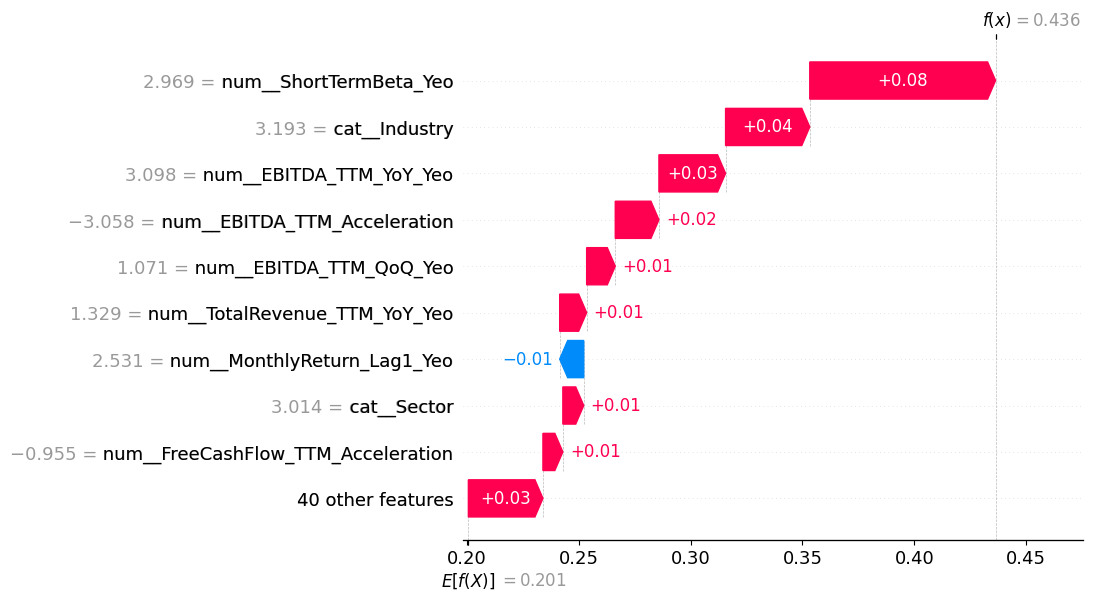

In [13]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test.values == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP
    shap_values = explainer(X_ticker_eval)
    
    # --- NUEVO: Seleccionar la explicación específica para la clase 5 (Quintil 5) ---
    idx_q5 = list(rf_model.classes_).index(5)
    shap_values_q5 = shap_values[..., idx_q5]
    
    print(f"--- Explicación de la probabilidad de ser Quintil 5 para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada
    shap.plots.waterfall(shap_values_q5[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [ ]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest Classifier"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el clasificador
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestClassifier(random_state=42)) # Cambiado a Classifier
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV con la métrica correcta
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='accuracy', # Cambiado a accuracy (puedes usar 'balanced_accuracy' también)
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)